In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/dataset-major/CC_6/623.jpg
/kaggle/input/dataset-major/CC_6/764.jpg
/kaggle/input/dataset-major/CC_6/1075.jpg
/kaggle/input/dataset-major/CC_6/771.jpg
/kaggle/input/dataset-major/CC_6/208.jpg
/kaggle/input/dataset-major/CC_6/820.jpg
/kaggle/input/dataset-major/CC_6/473.jpg
/kaggle/input/dataset-major/CC_6/1031.jpg
/kaggle/input/dataset-major/CC_6/333.jpg
/kaggle/input/dataset-major/CC_6/1024.jpg
/kaggle/input/dataset-major/CC_6/537.jpg
/kaggle/input/dataset-major/CC_6/45.jpg
/kaggle/input/dataset-major/CC_6/369.jpg
/kaggle/input/dataset-major/CC_6/56.jpg
/kaggle/input/dataset-major/CC_6/654.jpg
/kaggle/input/dataset-major/CC_6/89.jpg
/kaggle/input/dataset-major/CC_6/20.jpg
/kaggle/input/dataset-major/CC_6/275.jpg
/kaggle/input/dataset-major/CC_6/1161.jpg
/kaggle/input/dataset-major/CC_6/785.jpg
/kaggle/input/dataset-major/CC_6/212.jpg
/kaggle/input/dataset-major/CC_6/239.jpg
/kaggle/input/dataset-major/CC_6/792.jpg
/kaggle/input/dataset-major/CC_6/1009.jpg
/kaggle/input/d

In [2]:
!pip install wandb
from kaggle_secrets import UserSecretsClient
import wandb
user_secrets = UserSecretsClient()

my_secret = user_secrets.get_secret("wandb_api_key") 

wandb.login(key=my_secret)

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: 077bct076-sandhya (077bct076-sandhya-pulchowk-campus). Use `wandb login --relogin` to force relogin
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


True

In [2]:
# CFG = {
#     'model_name' : 'Inception v3',
#     'BATCH_SIZE' : 32,
#     'LEARNING_RATE' : 0.001,
#     'MOMENTUM' : 0.9,
#     'STEP_SIZE' : 7,
#     'GAMMA' : 0.1,
#     'EPOCHS' : 15,
#     'TRAIN_DIR' : '/kaggle/input/prasansa-data/DevanagariHandwrittenCharacterDataset/Train',
#     'TEST_DIR' : '/kaggle/input/prasansa-data/DevanagariHandwrittenCharacterDataset/Test'
# }

# # Initialise run
# run = wandb.init(project = 'devnagari_character_recog',
#                  config = CFG,
#                  save_code = True,
#                  name='inception_v3_train'
#                  #group = 'ANN',
#                  #job_type = 'train'
# )

In [3]:
#resnet walaon our dataset
CFG = {
    'model_name' : 'RESNET-34',
    'BATCH_SIZE' : 32,
    'LEARNING_RATE' : 0.001,
    'MOMENTUM' : 0.9,
    'STEP_SIZE' : 7,
    'GAMMA' : 0.1,
    'EPOCHS' : 15,
    'TRAIN_DIR' : '/kaggle/input/dataset-major',
    # 'TEST_DIR' : '/kaggle/input/prasansa-data/DevanagariHandwrittenCharacterDataset/Test'
}

# Initialise run
run = wandb.init(project = 'devnagari_character_recog',
                 config = CFG,
                 save_code = True,
                 name='RESNET-34_train'
                 #group = 'ANN',
                 #job_type = 'train'
)

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torchvision
from torchvision import datasets, models, transforms
import numpy as np
import matplotlib.pyplot as plt
import os
import time
import copy
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd
from torch.utils.data import DataLoader, random_split, Dataset

# Set device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


In [5]:
# Hyperparameters
BATCH_SIZE = CFG['BATCH_SIZE']
LEARNING_RATE = CFG['LEARNING_RATE']
MOMENTUM = CFG['MOMENTUM']
STEP_SIZE = CFG['STEP_SIZE']
GAMMA = CFG['GAMMA']
EPOCHS = CFG['EPOCHS']

TRAIN_DIR = CFG['TRAIN_DIR']
TEST_DIR = CFG['TEST_DIR']

In [6]:
# Custom Dataset wrapper for applying transforms
class TransformedSubset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

In [10]:
# # Data transforms
# augment_transform = transforms.Compose([
#     transforms.Resize(224),
#     transforms.RandomRotation(10),
#     transforms.RandomHorizontalFlip(),
#     transforms.RandomCrop(224),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])

# test_transform = transforms.Compose([
#     transforms.Resize(224),
#     transforms.CenterCrop(224),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])

# # Load dataset and split
# full_dataset = datasets.ImageFolder(root=TRAIN_DIR)
# train_size = int(0.8 * len(full_dataset))
# val_size = len(full_dataset) - train_size
# train_subset, val_subset = random_split(full_dataset, [train_size, val_size])

# # Create datasets
# no_augment_train = TransformedSubset(train_subset, test_transform)
# augment_train = TransformedSubset(train_subset, augment_transform)
# val_dataset = TransformedSubset(val_subset, test_transform)

# # Create dataloaders
# no_augment_loader = DataLoader(no_augment_train, BATCH_SIZE, shuffle=True)
# augment_loader = DataLoader(augment_train, BATCH_SIZE, shuffle=True)
# val_loader = DataLoader(val_dataset, BATCH_SIZE, shuffle=False)

# num_classes = len(full_dataset.classes)


In [7]:
print(len(full_dataset.classes))

NameError: name 'full_dataset' is not defined

In [49]:
torch.cuda.empty_cache()


RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [50]:
for inputs, labels in train_loader:
    print("Max label:", labels.max().item(), "Min label:", labels.min().item())
    break  # Only check the first batch


Max label: 40 Min label: 0


In [55]:
# Check the dataset classes
print(full_dataset.classes)  # This should print a list of 41 class names


['CC_1', 'CC_10', 'CC_11', 'CC_12', 'CC_13', 'CC_14', 'CC_15', 'CC_16', 'CC_17', 'CC_18', 'CC_19', 'CC_2', 'CC_20', 'CC_21', 'CC_22', 'CC_23', 'CC_24', 'CC_25', 'CC_26', 'CC_27', 'CC_28', 'CC_29', 'CC_3', 'CC_30', 'CC_31', 'CC_32', 'CC_33', 'CC_34', 'CC_35', 'CC_36', 'CC_37', 'CC_38', 'CC_39', 'CC_4', 'CC_40', 'CC_41', 'CC_5', 'CC_6', 'CC_7', 'CC_8', 'CC_9']


In [8]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Data transforms
train_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomRotation(10),
    transforms.RandomCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load full dataset
full_dataset = datasets.ImageFolder(root=TRAIN_DIR)

# Split into train (80%) and validation (20%)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_subset, val_subset = random_split(full_dataset, [train_size, val_size])

# Apply transforms to train and validation sets
train_dataset = TransformedSubset(train_subset, train_transform)
val_dataset = TransformedSubset(val_subset, val_transform)

# Create dataloaders
train_loader = DataLoader(train_dataset, BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, BATCH_SIZE, shuffle=False)

# Get number of classes
num_classes = len(full_dataset.classes)


In [9]:
print(len(full_dataset.classes))

41


In [ ]:
# class ownModel(nn.Module):
#     def __init__(self, num_classes):
#         self.model = models.resnet34(pretrained=True)
#         self.num_ftrs = model.fc.in_features
#         self.fc = nn.Linear(self.num_ftrs, num_classes)

#     def forward(self,x):
#         _x = self.model(x)
#         return self.fc(_x)

In [39]:
# # Define the Inception V3 model
# class InceptionV3Model(nn.Module):
#     def __init__(self, num_classes):
#         super(InceptionV3Model, self).__init__()
#         self.model = models.inception_v3(pretrained=True)
#         self.fc = nn.Linear(1000, num_classes)
    
#     def forward(self, x):
#         _x = self.model(x)
#         _op = self.fc(_x[0])
#         return _x, _op


In [35]:
# Define the Inception V3 model
class InceptionV3Model(nn.Module):
    def __init__(self, num_classes):
        super(InceptionV3Model, self).__init__()
        self.model = models.inception_v3(pretrained=True)
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)
    
    def forward(self, x):
        _x = self.model(x)
        return _x[0]

Error in callback <bound method _WandbInit._pause_backend of <wandb.sdk.wandb_init._WandbInit object at 0x79584823c6d0>> (for post_run_cell):


KeyboardInterrupt: 

In [52]:
# Instantiate the model
model = InceptionV3Model(num_classes=num_classes)

In [58]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'


In [10]:

def create_model(num_classes=41):
    model = models.resnet34(pretrained=True)
    model.fc = nn.Linear(model.fc.in_features, num_classes)  # Adjust for 41 classes
    return model

In [11]:
def train_model(train_loader, val_loader, name):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = create_model().to(device)
    # Tensor.cpu()
    criterion = nn.CrossEntropyLoss()    #TENSOR
    optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=MOMENTUM)
    scheduler = lr_scheduler.StepLR(optimizer, STEP_SIZE, GAMMA)

    best_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(EPOCHS):
        print(f'Epoch {epoch+1}/{EPOCHS}')
        model.train()
        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(inputs)
            if isinstance(outputs, torch.nn.modules.container.ModuleDict):
                outputs = outputs.logits  # Extract only the main output
            loss = criterion(outputs, labels)

            # outputs = model(inputs)       #INCEPTIONOUTPUT
            # loss = criterion(outputs, labels) #EXPECTS TENSOR
            loss.backward()
            optimizer.step()
            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        scheduler.step()
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.double() / len(train_loader.dataset)
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc)

        print('hello')

        # Validation
        model.eval()
        val_loss = 0.0
        val_corrects = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)
                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)

        val_epoch_loss = val_loss / len(val_loader.dataset)
        val_epoch_acc = val_corrects.double() / len(val_loader.dataset)
        history['val_loss'].append(val_epoch_loss)
        history['val_acc'].append(val_epoch_acc)

        print(f'{name} Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
        print(f'{name} Val Loss: {val_epoch_loss:.4f} Acc: {val_epoch_acc:.4f}\n')
        
        wandb.log({f'{name} Train Loss': epoch_loss})
        wandb.log({f'{name} Train Accuracy': epoch_acc.cpu().numpy()})
        wandb.log({f'{name} Val Loss': val_epoch_loss})
        wandb.log({f'{name} Val Accuracy': val_epoch_acc.cpu().numpy()})
        SAVE_PATH = '/kaggle/working/RESNET_34_MAJOR.torch'
        if val_epoch_acc > best_acc:
            
            best_acc = val_epoch_acc
            best_model = copy.deepcopy(model.state_dict())
            torch.save(best_model, SAVE_PATH)
            wandb.save(SAVE_PATH)

    model.load_state_dict(best_model)
    wandb.finish()
    return model, history


In [12]:
print(f"Number of classes: {num_classes}")
for _, labels in train_loader:
    print(f"Label range: {labels.min()} to {labels.max()}")
    break  # Print only one batch


Number of classes: 41
Label range: 1 to 38


In [42]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'


In [15]:
# Train without augmentation
print("Training without augmentation...")
model_no_aug, hist_no_aug = train_model(no_augment_loader, val_loader, "No Aug")



Training without augmentation...


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 209MB/s]


Epoch 1/15


KeyboardInterrupt: 

In [14]:
# Train with augmentation
print("\nTraining with augmentation...")
model_aug, hist_aug = train_model(train_loader, val_loader, "Aug")


Training with augmentation...


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 177MB/s] 


Epoch 1/15
hello


wandb: WARNING Saving files without folders. If you want to preserve subdirectories pass base_path to wandb.save, i.e. wandb.save("/mnt/folder/file.h5", base_path="/mnt")


Aug Train Loss: 0.5073 Acc: 0.8947
Aug Val Loss: 0.0640 Acc: 0.9826

Epoch 2/15
hello
Aug Train Loss: 0.0579 Acc: 0.9861
Aug Val Loss: 0.0425 Acc: 0.9869

Epoch 3/15
hello
Aug Train Loss: 0.0358 Acc: 0.9909
Aug Val Loss: 0.0360 Acc: 0.9894

Epoch 4/15
hello
Aug Train Loss: 0.0245 Acc: 0.9939
Aug Val Loss: 0.0396 Acc: 0.9883

Epoch 5/15
hello
Aug Train Loss: 0.0175 Acc: 0.9960
Aug Val Loss: 0.0323 Acc: 0.9896

Epoch 6/15
hello
Aug Train Loss: 0.0138 Acc: 0.9970
Aug Val Loss: 0.0341 Acc: 0.9893

Epoch 7/15
hello
Aug Train Loss: 0.0112 Acc: 0.9973
Aug Val Loss: 0.0308 Acc: 0.9912

Epoch 8/15
hello
Aug Train Loss: 0.0072 Acc: 0.9986
Aug Val Loss: 0.0301 Acc: 0.9916

Epoch 9/15
hello
Aug Train Loss: 0.0067 Acc: 0.9988
Aug Val Loss: 0.0298 Acc: 0.9915

Epoch 10/15
hello
Aug Train Loss: 0.0063 Acc: 0.9987
Aug Val Loss: 0.0288 Acc: 0.9920

Epoch 11/15
hello
Aug Train Loss: 0.0061 Acc: 0.9991
Aug Val Loss: 0.0279 Acc: 0.9922

Epoch 12/15
hello
Aug Train Loss: 0.0053 Acc: 0.9992
Aug Val Loss: 0.

Aug Train Accuracy,▁▇▇████████████
Aug Train Loss,█▂▁▁▁▁▁▁▁▁▁▁▁▁▁
Aug Val Accuracy,▁▄▆▅▆▆▇█▇███▇▇█
Aug Val Loss,█▄▃▃▂▂▂▁▁▁▁▁▁▁▁
Aug Train Accuracy,0.99915
Aug Train Loss,0.00527
Aug Val Accuracy,0.9921
Aug Val Loss,0.02835


In [47]:
model = create_model()
print(model.fc)  # Check if the output layer has 41 units




Linear(in_features=512, out_features=41, bias=True)


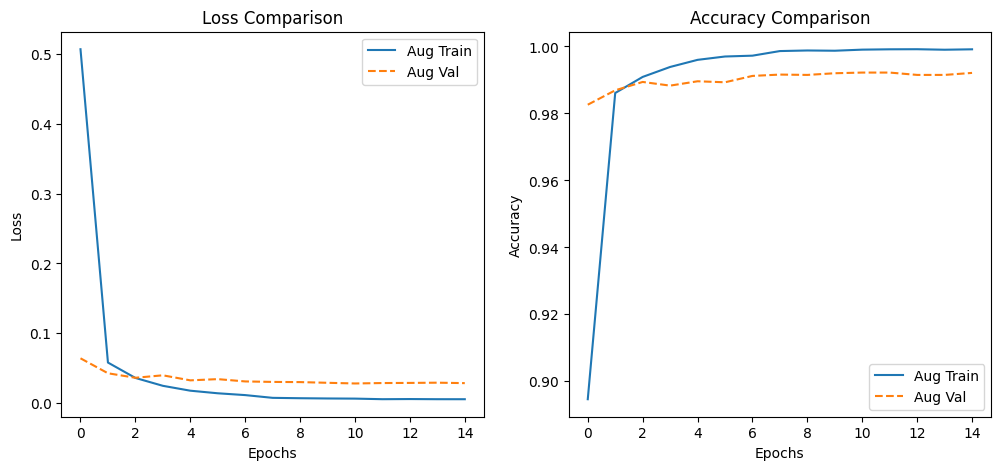

In [15]:
# Convert tensors to CPU numpy arrays before plotting
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(hist_aug['train_loss'], label='Aug Train')
plt.plot(hist_aug['val_loss'], '--', label='Aug Val')
plt.title('Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot([acc.cpu().numpy() for acc in hist_aug['train_acc']], label='Aug Train')
plt.plot([acc.cpu().numpy() for acc in hist_aug['val_acc']], '--', label='Aug Val')
plt.title('Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


In [24]:
# Test evaluation
test_dataset = datasets.ImageFolder(TRAIN_DIR, train_transform)
test_loader = DataLoader(test_dataset, BATCH_SIZE, shuffle=False)


def evaluate(model, loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    all_preds = []
    all_labels = []
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    
    accuracy = 100 * correct / total
    return all_labels, all_preds, accuracy

# Evaluate best model
labels, preds, test_acc = evaluate(model_aug, test_loader)
print("Test Results:")
print(classification_report(labels, preds, target_names=test_dataset.classes))
print(f"Test Accuracy: {test_acc:.2f}%")


Test Results:
                           precision    recall  f1-score   support

         character_10_yna       1.00      1.00      1.00       300
    character_11_taamatar       1.00      0.99      0.99       300
        character_12_thaa       1.00      1.00      1.00       300
         character_13_daa       0.99      0.99      0.99       300
        character_14_dhaa       0.99      0.99      0.99       300
        character_15_adna       1.00      1.00      1.00       300
      character_16_tabala       0.98      1.00      0.99       300
         character_17_tha       0.99      1.00      1.00       300
          character_18_da       0.99      0.98      0.99       300
         character_19_dha       1.00      0.99      0.99       300
           character_1_ka       1.00      1.00      1.00       300
          character_20_na       1.00      0.99      1.00       300
          character_21_pa       1.00      1.00      1.00       300
         character_22_pha       1.00      1.00 

In [16]:
# Compute the confusion matrix
cm = confusion_matrix(labels, preds)

# Plot the confusion matrix
plt.figure(figsize=(20, 20))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=train_dataset.classes, 
            yticklabels=train_dataset.classes)

# Labels and title
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')

# Show the plot
plt.show()

NameError: name 'preds' is not defined